# Circadian cycles Analysis Vaga Renfe - 2024

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import powerlaw, truncnorm, ks_2samp
import powerlaw
import random

# Simple trapezoid integration for NumPy 2.0+ compatibility
def trapz(y, x):
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)

In [ ]:
# >>> FIGURE OUTPUT SETUP (added) <<<
# Per-user CCDF figures are written here as PDFs (one subfolder per dataset).
import os
FIG_DIR = os.path.join('figures', "RENFE'24")
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Figures will be saved under: {FIG_DIR}')


In [17]:
# import datasets
df = pd.read_json("../../../Datasets/vagarenfe.json") # Import data from Vaga renfe GC

## Prepare data

In [18]:
def normalize_data(df):
    df["id"]= pd.to_numeric(df["id"], errors='coerce').astype('Int64')   # Convert 'id' to numeric, coercing errors to NaN.
    df["sender_id"]= pd.to_numeric(df["sender_id"], errors='coerce').astype('Int64')   # Convert 'sender_id' to numeric, coercing errors to NaN.
    df["date"]= pd.to_datetime(df["date"], errors='coerce')   # Convert 'date' to datetime, coercing errors to NaT.
    df["edit_date"]= pd.to_datetime(df["edit_date"], errors='coerce')   # Convert 'edit_date' to datetime, coercing errors to NaT.
    df["reply_to_msg_id"]= pd.to_numeric(df["reply_to_msg_id"], errors='coerce').astype('Int64')   # Convert 'reply_to_message_id' to numeric, coercing errors to NaN.
    df["views"]= pd.to_numeric(df["views"], errors='coerce').astype('Int64')   # Convert 'views' to numeric, coercing errors to NaN.
    df["forwards"]= pd.to_numeric(df["forwards"], errors='coerce').astype('Int64')   # Convert 'forwards' to numeric, coercing errors to NaN.
    return df
df = normalize_data(df) # Normalize the data types of the DataFrame columns.

# Filter to only 2024 messages
df = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-12-31')]
print(f"Messages in 2024: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Messages in 2024: 17576
Date range: 2024-01-01 04:30:44+00:00 to 2024-12-30 23:09:16+00:00


In [19]:
# Gather users with more than 100 messages in the groupchat during 2024.
user_message_counts = df['sender_id'].value_counts()
active_users = user_message_counts[user_message_counts > 100].index.tolist()
active_users_message_counts = user_message_counts[user_message_counts > 100]
# Print the number of active users.
print(f"Number of active users (more than 100 messages in 2024): {len(active_users)}")

Number of active users (more than 100 messages in 2024): 30


In [20]:
df = df.sort_values('date') # Sort messages by date to calculate inter-event times correctly.

# Calcular inter-event times en segundos
df['iet'] = df['date'].diff().dt.total_seconds()

In [21]:
import ast, os

def _parse_array(s):
    """Parse a numpy-array repr string back to a float array."""
    cleaned = s.strip().replace('\n', ' ')
    if ',' not in cleaned:
        cleaned = cleaned.replace('[', '').replace(']', '')
        return np.array([float(x) for x in cleaned.split()])
    return np.array(ast.literal_eval(cleaned))

RESULTS_CSV = 'circadian_cycles_vagarenfe_2024_results.csv'

if os.path.exists(RESULTS_CSV):
    saved = pd.read_csv(RESULTS_CSV)
    parameters_users = {}
    pvalues_users    = {}
    for _, row in saved.iterrows():
        uid = int(row['user_id'])
        parameters_users[uid] = {
            'rho_a': float(row['rho_a']),
            'Nw':    float(row['Nw']),
            'pd_t':  _parse_array(row['pd_t']),
            'pw_t':  _parse_array(row['pw_t']),
            'p_Na':  _parse_array(row['p_Na']),
            'A_best': float(row['A_best']),
        }
        pvalues_users[uid] = float(row['p_value']) if 'p_value' in row and pd.notna(row['p_value']) else np.nan
    print(f"Loaded {len(parameters_users)} users from {RESULTS_CSV} — skipping SA and Monte Carlo.")
else:
    parameters_users = None
    pvalues_users = {}
    print(f"{RESULTS_CSV} not found — will run SA and Monte Carlo from scratch.")

Loaded 30 users from circadian_cycles_vagarenfe_2024_results.csv — skipping SA and Monte Carlo.


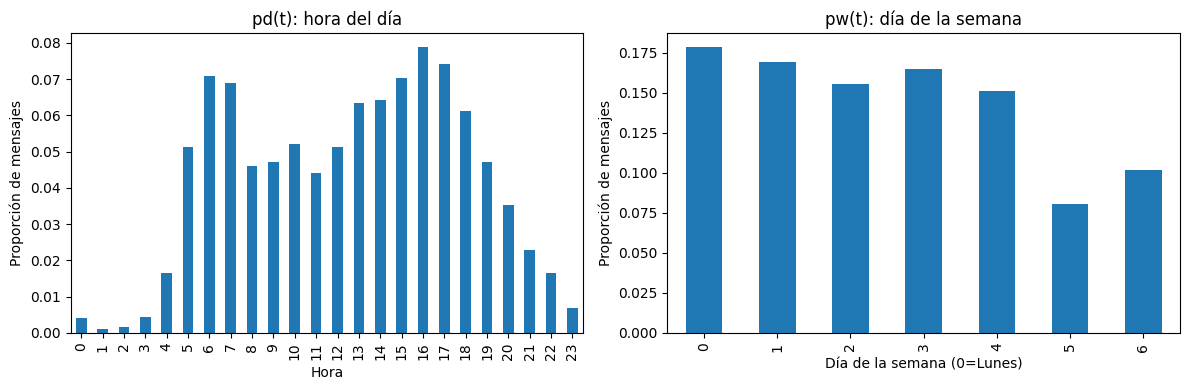

In [22]:
df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.weekday  # 0=lunes

if df.empty:
    print("df está vacío: no hay datos para 2024. Revisa el filtrado de fechas.")
else:
    # pd(t): distribución por hora del día (aseguramos horas 0-23)
    hours = list(range(24))
    pd_t_counts = df.groupby('hour').size()
    pd_t = pd_t_counts.reindex(hours, fill_value=0) / len(df)

    # pw(t): distribución por día de la semana (aseguramos días 0-6)
    days = list(range(7))
    pw_t_counts = df.groupby('weekday').size()
    pw_t = pw_t_counts.reindex(days, fill_value=0) / len(df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    pd_t.plot(kind='bar', ax=axes[0], title='pd(t): hora del día')
    pw_t.plot(kind='bar', ax=axes[1], title='pw(t): día de la semana')
    axes[0].set_xlabel('Hora')
    axes[0].set_ylabel('Proporción de mensajes')
    axes[1].set_xlabel('Día de la semana (0=Lunes)')
    axes[1].set_ylabel('Proporción de mensajes')
    plt.tight_layout()
    plt.show()

## Active intervals identification (Annealing)

In [23]:
def compute_model_params(events, active_config):
    """
    events: array de tiempos en HORAS.
    active_config: bool array N. True = mismo AI que el evento anterior.
    """
    iets = np.diff(events)
    iet_active = iets[active_config[1:]]
    rho_a = 1.0 / np.mean(iet_active) if len(iet_active) > 0 else 0

    n_active_intervals = np.sum(~active_config[1:]) + 1
    total_weeks = (events[-1] - events[0]) / (7 * 24)
    Nw = n_active_intervals / total_weeks if total_weeks > 0 else 0

    starts_idx = np.where(~active_config[1:])[0] + 1
    start_times = np.concatenate([events[:1], events[starts_idx]])
    hours    = start_times % 24
    weekdays = (start_times / 24) % 7

    pd_counts, _ = np.histogram(hours,    bins=24, range=(0, 24))
    pw_counts, _ = np.histogram(weekdays, bins=7,  range=(0, 7))
    pd_t = pd_counts / pd_counts.sum() if pd_counts.sum() > 0 else np.zeros(24)
    pw_t = pw_counts / pw_counts.sum() if pw_counts.sum() > 0 else np.zeros(7)
    return rho_a, Nw, pd_t, pw_t


def get_pNa(config):
    """
    Distribución empírica de Na. config: bool array N-1, True = par (i,i+1) en el mismo AI.
    """
    na_counts, count = [], 0
    for c in config:
        if c:
            count += 1
        else:
            na_counts.append(count)
            count = 0
    na_counts.append(count)
    hist = np.bincount(na_counts)
    return hist / hist.sum()


def init_threshold(iets):
    """
    Calcula el umbral iterativamente: threshold = 0.1/rho_primary = 0.1 * mean_iet * (1+mean_Na).
    """
    pos = iets[iets > 0]
    if len(pos) < 20:
        return np.median(pos)

    mean_iet  = np.mean(pos)
    threshold = 0.1 * mean_iet

    for _ in range(15):
        n_within  = int(np.sum(pos < threshold))
        n_between = int(np.sum(pos >= threshold))
        mean_Na_est   = n_within / max(n_between, 1)
        threshold_new = 0.1 * mean_iet * (1 + mean_Na_est)
        if abs(threshold_new - threshold) < 1e-6 * mean_iet:
            break
        threshold = threshold_new

    return threshold_new


def area_test_statistic(empirical_iet, model_iet, n_bins=100, eps=1e-6):
    emp = np.asarray(empirical_iet)
    mod = np.asarray(model_iet)
    emp = emp[np.isfinite(emp) & (emp > 0)]
    mod = mod[np.isfinite(mod) & (mod > 0)]
    if len(emp) == 0 or len(mod) == 0:
        return np.inf
    lo = max(emp.min(), mod.min(), eps)
    hi = max(emp.max(), mod.max(), lo * 10)
    log_bins = np.logspace(np.log10(lo), np.log10(hi), n_bins)
    ccdf_emp = np.array([np.mean(emp > b) for b in log_bins])
    ccdf_mod = np.array([np.mean(mod > b) for b in log_bins])
    return trapz(np.abs(ccdf_emp - ccdf_mod), np.log(log_bins))


def simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, n_samples=None):
    """
    Simula el cascading NHPP del paper Malmgren et al. (2008).
    Proceso primario: NHPP con tasa rho(t) = Nw * pd(t) * pw(t).
    Proceso secundario: HPP con tasa rho_a dentro de cada active interval.
    """
    pd_t_arr = np.asarray(pd_t, dtype=float)
    pw_t_arr = np.asarray(pw_t, dtype=float)
    pd_t_arr = pd_t_arr / pd_t_arr.sum()
    pw_t_arr = pw_t_arr / pw_t_arr.sum()
    p_Na_norm = np.asarray(p_Na, dtype=float)
    p_Na_norm = p_Na_norm / p_Na_norm.sum()

    mean_Na = np.dot(np.arange(len(p_Na_norm)), p_Na_norm)

    sim_hours = total_hours
    if n_samples is not None and Nw > 0:
        expected_events = Nw * (total_hours / (7 * 24)) * (1 + mean_Na)
        if expected_events < n_samples:
            sim_hours = total_hours * (n_samples / max(1, expected_events)) * 1.5

    n_weeks = sim_hours / (7 * 24)

    joint = np.outer(pw_t_arr, pd_t_arr).flatten()
    joint /= joint.sum()

    n_bursts = np.random.poisson(max(1.0, Nw * n_weeks))

    week_nums = np.random.uniform(0, n_weeks, n_bursts)
    slots = np.random.choice(168, size=n_bursts, p=joint)

    burst_times = (
        np.floor(week_nums) * 7 * 24
        + (slots // 24) * 24
        + (slots % 24)
        + np.random.uniform(0, 1, n_bursts)
    )
    burst_times = np.sort(burst_times)
    burst_times = burst_times[burst_times < sim_hours]

    if rho_a <= 0:
        rho_a = 1.0

    events = []
    for bt in burst_times:
        events.append(bt)
        Na = np.random.choice(len(p_Na_norm), p=p_Na_norm)
        t = bt
        for _ in range(Na):
            t += np.random.exponential(1.0 / rho_a)
            events.append(t)

    result = np.sort(np.array(events))

    if n_samples is not None:
        return result[:n_samples]
    return result


def simulated_annealing(events_hours, n_iter=5000, T_init=1.0, cooling=0.95, n_sim=None):
    """
    Simulated Annealing para identificar active intervals (Malmgren et al. 2008, SI).

    Correcciones:
      (1) pd_t y pw_t se fijan antes del SA y no se recalculan (SI Simplification #2).
      (2) Solo se proponen flips para pares con τ < threshold (SI Simplification #3).
      (3) cool_every = n_iter // 50 garantiza ~50 pasos de enfriamiento.
    """
    N    = len(events_hours)
    iets = np.diff(events_hours)
    if n_sim is None:
        n_sim = max(5000, 10 * N)

    all_hours    = events_hours % 24
    all_weekdays = (events_hours / 24) % 7
    pd_counts, _ = np.histogram(all_hours,    bins=24, range=(0, 24))
    pw_counts, _ = np.histogram(all_weekdays, bins=7,  range=(0, 7))
    pd_t_fixed = pd_counts / pd_counts.sum() if pd_counts.sum() > 0 else np.ones(24) / 24
    pw_t_fixed = pw_counts / pw_counts.sum() if pw_counts.sum() > 0 else np.ones(7) / 7

    def compute_area(cfg):
        rho_a, Nw, _, _ = compute_model_params(
            events_hours, np.concatenate([[False], cfg])
        )
        p_Na = get_pNa(cfg)
        model_events = simulate_cascading_nhpp(
            rho_a, Nw, pd_t_fixed, pw_t_fixed, p_Na,
            total_hours=events_hours[-1] - events_hours[0],
            n_samples=n_sim
        )
        if len(model_events) > 1:
            return area_test_statistic(iets, np.diff(model_events))
        return np.inf

    threshold = init_threshold(iets)
    config    = iets < threshold

    mergeable = np.where(iets < threshold)[0]
    if len(mergeable) == 0:
        mergeable = np.arange(N - 1)

    print(f"  Init: {config.mean():.1%} pares mergeados  "
          f"(threshold={threshold:.4f}h = {threshold*60:.1f}min, "
          f"candidatos={len(mergeable)}/{N-1})")

    T           = T_init
    best_config = config.copy()
    A_current   = compute_area(config)
    A_best      = A_current

    cool_every = max(1, n_iter // 50)

    for iteration in range(n_iter):
        idx        = mergeable[random.randint(0, len(mergeable) - 1)]
        new_config = config.copy()
        new_config[idx] = not new_config[idx]

        A_new = compute_area(new_config)
        delta = A_new - A_current
        if delta < 0 or random.random() < np.exp(-delta / T):
            config    = new_config
            A_current = A_new
            if A_new < A_best:
                A_best      = A_new
                best_config = new_config.copy()

        if (iteration + 1) % cool_every == 0:
            T *= cooling

    return best_config, A_best

In [24]:
# Guardar parámetros por usuario
if parameters_users is None:
    parameters_users = {}
    i=0
    for user_id in active_users:
        print(f"Procesando usuario {user_id}... ({i+1}/{len(active_users)})")
        i += 1
        user_events = df[df['sender_id'] == user_id]['date'].sort_values()
        if len(user_events) < 2:
            continue

        events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600

        best_config, A_best = simulated_annealing(events_hours.values)

        rho_a, Nw, pd_t, pw_t = compute_model_params(
            events_hours.values,
            np.concatenate([[False], best_config])
        )
        p_Na = get_pNa(best_config)

        parameters_users[user_id] = {
            'rho_a': rho_a,
            'Nw': Nw,
            'pd_t': pd_t,
            'pw_t': pw_t,
            'p_Na': p_Na,
            'A_best': A_best
        }
else:
    print("Skipping SA — parameters already loaded from CSV.")

Skipping SA — parameters already loaded from CSV.


In [25]:
print("Parámetros estimados para usuarios activos:")
for user_id, params in parameters_users.items():
    print(f"Usuario {user_id}: rho_a={params['rho_a']:.4f}, Nw={params['Nw']:.4f}, A_best={params['A_best']:.4f}, pd_t={params['pd_t']}, pw_t={params['pw_t']}")

Parámetros estimados para usuarios activos:
Usuario 274636082: rho_a=2.0757, Nw=6.9015, A_best=0.8406, pd_t=[0.05070423 0.11267606 0.07323944 0.06760563 0.07042254 0.02253521
 0.         0.0056338  0.         0.         0.0056338  0.02535211
 0.03661972 0.06760563 0.02816901 0.01690141 0.03943662 0.04225352
 0.02253521 0.02816901 0.03098592 0.08169014 0.10985915 0.06197183], pw_t=[0.14647887 0.14647887 0.13239437 0.16619718 0.13521127 0.14366197
 0.12957746]
Usuario 6988965722: rho_a=2.6828, Nw=6.8100, A_best=0.6210, pd_t=[0.05813953 0.03197674 0.03197674 0.02034884 0.00872093 0.02034884
 0.00872093 0.00872093 0.00290698 0.00872093 0.02616279 0.03197674
 0.08139535 0.07848837 0.04651163 0.06686047 0.05523256 0.04069767
 0.05232558 0.05523256 0.03488372 0.05813953 0.10174419 0.06976744], pw_t=[0.20930233 0.09883721 0.24709302 0.11918605 0.09302326 0.10465116
 0.12790698]
Usuario 4473225: rho_a=3.9250, Nw=3.7493, A_best=1.7534, pd_t=[0.07692308 0.07692308 0.06666667 0.06666667 0.02564103

In [26]:
# Simular cascadas para cada usuario con los parámetros estimados por SA
simulated_cascades = {}
for user_id, params in parameters_users.items():
    user_events = df[df['sender_id'] == user_id]['date'].sort_values()
    total_hours = (user_events.iloc[-1] - user_events.iloc[0]).total_seconds() / 3600
    n_events = len(user_events)

    sim_events = simulate_cascading_nhpp(
        params['rho_a'], params['Nw'], params['pd_t'], params['pw_t'],
        p_Na=params['p_Na'],      # distribución empírica estimada por SA
        total_hours=total_hours,
        n_samples=n_events
    )
    simulated_cascades[user_id] = sim_events

In [ ]:
# Empirical CCDF vs CNHPP model  (per-user PDF + combined multipage PDF)
from matplotlib.backends.backend_pdf import PdfPages

_sub = os.path.join(FIG_DIR, 'empirical_vs_cnhpp')
os.makedirs(_sub, exist_ok=True)
_combined = PdfPages(os.path.join(FIG_DIR, 'ALL_empirical_vs_cnhpp.pdf'))

def _plot_ccdf(ax, data, **kwargs):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data) & (data > 0)]
    if len(data) == 0:
        return
    x = np.sort(data)
    y = 1.0 - np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where='post', **kwargs)

_n = 0
for user_id in active_users:
    if user_id not in simulated_cascades:
        continue
    user_events = df[df['sender_id'] == user_id]['date'].sort_values()
    if len(user_events) < 2:
        continue

    real_iets = np.diff((user_events - user_events.iloc[0]).dt.total_seconds() / 3600)
    sim_iets  = np.diff(simulated_cascades[user_id])
    real_iets = np.asarray(real_iets, dtype=float)
    sim_iets  = np.asarray(sim_iets,  dtype=float)
    real_iets = real_iets[np.isfinite(real_iets) & (real_iets > 0)]
    sim_iets  = sim_iets[np.isfinite(sim_iets) & (sim_iets > 0)]
    if len(real_iets) < 2:
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    _plot_ccdf(ax, real_iets, label='Empirical',   color='crimson',   lw=1.8)
    _plot_ccdf(ax, sim_iets,  label='CNHPP model', color='steelblue', lw=1.8)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Inter-event time (hours)'); ax.set_ylabel(r'CCDF  P(IET > $\tau$)')
    ax.set_title(f'User {user_id} - Empirical vs CNHPP model')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.5)
    fig.tight_layout()
    fig.savefig(os.path.join(_sub, f'user_{user_id}.pdf'), bbox_inches='tight')
    _combined.savefig(fig, bbox_inches='tight')
    plt.close(fig)
    _n += 1

_combined.close()
print(f'[empirical vs CNHPP] saved {_n} per-user PDFs in {_sub} + ALL_empirical_vs_cnhpp.pdf')


## Montecarlo Testing

In [28]:
def monte_carlo_pvalue(empirical_iet, model_params, M=100, sa_iter=5000):
    """
    Test de hipótesis Monte Carlo (Malmgren et al. 2008, Fig. S2).

    Procedimiento correcto:
      1. A = area(D, M(θ̂))
      2. Para s = 1..M:
           a. Ds ~ M(θ̂)
           b. SA sobre Ds → θ̂s
           c. Ms ~ M(θ̂s)
           d. As = area(Ds, Ms)
      3. p-valor (dos colas) = P(|As - ⟨As⟩| > |A - ⟨As⟩|)
    """
    rho_a, Nw, pd_t, pw_t, p_Na, total_hours = model_params
    N = len(empirical_iet) + 1

    model_events = simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, N)
    if len(model_events) < 2:
        return np.nan
    A_empirical = area_test_statistic(empirical_iet, np.diff(model_events))

    A_synthetic = []
    for s in range(M):
        print(f"  Monte Carlo réplica {s+1}/{M}...")
        syn_events = simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, N)
        if len(syn_events) < 4:
            continue

        syn_config, _ = simulated_annealing(syn_events, n_iter=sa_iter)
        rho_a_s, Nw_s, pd_t_s, pw_t_s = compute_model_params(
            syn_events, np.concatenate([[False], syn_config])
        )
        p_Na_s = get_pNa(syn_config)

        model_syn_events = simulate_cascading_nhpp(
            rho_a_s, Nw_s, pd_t_s, pw_t_s, p_Na_s, total_hours, len(syn_events)
        )
        if len(model_syn_events) < 2:
            continue

        A_s = area_test_statistic(np.diff(syn_events), np.diff(model_syn_events))
        A_synthetic.append(A_s)

    if len(A_synthetic) == 0:
        return np.nan

    A_synthetic = np.array(A_synthetic)
    A_mean = np.mean(A_synthetic)
    p_value = np.mean(np.abs(A_synthetic - A_mean) > np.abs(A_empirical - A_mean))
    return p_value

In [29]:
# Save info into csv for later analysis
results_df = pd.DataFrame({
    'user_id': list(parameters_users.keys()),
    'rho_a': [params['rho_a'] for params in parameters_users.values()],
    'pd_t': [params['pd_t'] for params in parameters_users.values()],
    'pw_t': [params['pw_t'] for params in parameters_users.values()],
    'p_Na': [params['p_Na'] for params in parameters_users.values()],
    'Nw': [params['Nw'] for params in parameters_users.values()],
    'A_best': [params['A_best'] for params in parameters_users.values()],

})
results_df.to_csv('circadian_cycles_vagarenfe_2024_results.csv', index=False)

In [30]:
# Calcular p-valores para cada usuario (M=20 para test; usar M=100, sa_iter=5000 para final)
# Skips automatically if p-values were already loaded from the CSV.
if pvalues_users and all(not np.isnan(v) for v in pvalues_users.values() if v is not None):
    print(f"Skipping Monte Carlo — {len(pvalues_users)} p-values already loaded from CSV.")
else:
    if not pvalues_users:
        pvalues_users = {}
    i = 0
    for user_id in active_users:
        if user_id not in parameters_users:
            continue
        if user_id in pvalues_users and not np.isnan(pvalues_users[user_id]):
            print(f"Skipping user {user_id} — p-value already available.")
            continue

        print(f"Calculando p-valor para usuario {user_id}... ({i+1}/{len(active_users)})")
        i += 1
        user_events = df[df['sender_id'] == user_id]['date'].sort_values()
        events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600
        empirical_iets = np.diff(events_hours.values)

        params = parameters_users[user_id]
        model_params = (
            params['rho_a'], params['Nw'], params['pd_t'],
            params['pw_t'], params['p_Na'],
            events_hours.iloc[-1] - events_hours.iloc[0]
        )

        p_value = monte_carlo_pvalue(empirical_iets, model_params, M=20, sa_iter=2000)
        pvalues_users[user_id] = p_value
        print(f"Usuario {user_id} - P-valor: {p_value:.4f}")

Calculando p-valor para usuario 274636082... (1/30)
  Monte Carlo réplica 1/20...
  Init: 68.5% pares mergeados  (threshold=2.8041h = 168.2min, candidatos=684/999)
  Monte Carlo réplica 2/20...
  Init: 68.2% pares mergeados  (threshold=3.1171h = 187.0min, candidatos=681/999)
  Monte Carlo réplica 3/20...
  Init: 68.5% pares mergeados  (threshold=2.8576h = 171.5min, candidatos=684/999)
  Monte Carlo réplica 4/20...
  Init: 71.2% pares mergeados  (threshold=2.9220h = 175.3min, candidatos=711/999)
  Monte Carlo réplica 5/20...
  Init: 69.2% pares mergeados  (threshold=2.7592h = 165.6min, candidatos=691/999)
  Monte Carlo réplica 6/20...
  Init: 71.0% pares mergeados  (threshold=2.8540h = 171.2min, candidatos=709/999)
  Monte Carlo réplica 7/20...
  Init: 74.9% pares mergeados  (threshold=3.0510h = 183.1min, candidatos=748/999)
  Monte Carlo réplica 8/20...
  Init: 72.4% pares mergeados  (threshold=2.7829h = 167.0min, candidatos=723/999)
  Monte Carlo réplica 9/20...
  Init: 70.0% pares me

In [31]:
print("\nP-valores de usuarios activos:")
for user_id, p_value in pvalues_users.items():
    print(f"Usuario {user_id}: p-valor={p_value:.4f}")


P-valores de usuarios activos:
Usuario 274636082: p-valor=0.0000
Usuario 6988965722: p-valor=0.0000
Usuario 4473225: p-valor=0.0000
Usuario 824741313: p-valor=0.0000
Usuario 412633448: p-valor=0.0000
Usuario 302926911: p-valor=0.0000
Usuario 1273291262: p-valor=0.0000
Usuario 1848901170: p-valor=0.0000
Usuario 1232695: p-valor=0.0000
Usuario 1091197048: p-valor=0.0000
Usuario 323949554: p-valor=0.0000
Usuario 8786749: p-valor=0.5500
Usuario 5561907303: p-valor=0.0000
Usuario 10589166: p-valor=0.0000
Usuario 5657126860: p-valor=0.0000
Usuario 1366797899: p-valor=0.0000
Usuario 1843524645: p-valor=0.0000
Usuario 940028943: p-valor=0.0000
Usuario 428716184: p-valor=0.0000
Usuario 1992063859: p-valor=0.0000
Usuario 32432053: p-valor=0.0000
Usuario 34343445: p-valor=0.0000
Usuario 170506767: p-valor=0.0000
Usuario 323309626: p-valor=0.0000
Usuario 459294324: p-valor=0.0000
Usuario 955992174: p-valor=0.0000
Usuario 5719413972: p-valor=0.0000
Usuario 185880661: p-valor=0.0000
Usuario 1134520

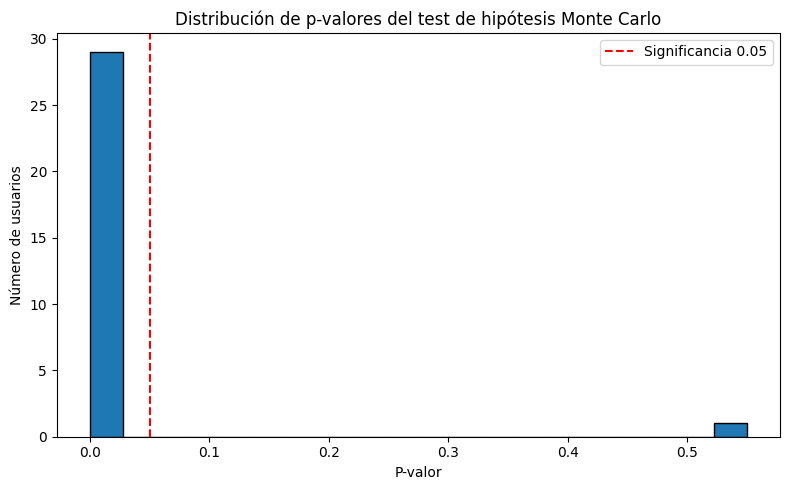

In [32]:
# plot p-valores
plt.figure(figsize=(8, 5))
plt.hist(list(pvalues_users.values()), bins=20, edgecolor='black')
plt.xlabel('P-valor')
plt.ylabel('Número de usuarios')
plt.title('Distribución de p-valores del test de hipótesis Monte Carlo')
plt.axvline(0.05, color='red', linestyle='--', label='Significancia 0.05')
plt.legend()
plt.tight_layout()
plt.show()

### Representación gráfica

In [33]:
def plot_log_residuals(empirical_iet, model_iet, title=''):
    """
    R = ln(p_model(τ) / p_empirical(τ))
    Si el modelo es bueno, R debe ser pequeño y sin estructura sistemática
    """
    log_bins = np.logspace(-2, 3, 50)  # en horas
    
    hist_emp, _ = np.histogram(empirical_iet, bins=log_bins, density=True)
    hist_mod, _ = np.histogram(model_iet, bins=log_bins, density=True)
    
    bin_centers = np.sqrt(log_bins[:-1] * log_bins[1:])
    
    # Evitar log(0)
    mask = (hist_emp > 0) & (hist_mod > 0)
    R = np.log(hist_mod[mask] / hist_emp[mask])
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.loglog(bin_centers[mask], hist_emp[mask], 'o', label='Datos SMS')
    plt.loglog(bin_centers[mask], hist_mod[mask], '-', label='Modelo CNHPP')
    plt.axvline(16, ls='--', color='gray', label='16h')
    plt.axvline(32, ls='--', color='gray', label='32h')
    plt.xlabel('Inter-event time (h)')
    plt.ylabel('PDF')
    plt.legend()
    plt.title(f'CCDF comparison {title}')
    
    plt.subplot(1, 2, 2)
    plt.semilogx(bin_centers[mask], R, 'o-')
    plt.axhline(0, color='k', ls='--')
    plt.axvspan(16, 32, alpha=0.2, color='red', label='Zona de interés')
    plt.xlabel('Inter-event time (h)')
    plt.ylabel('Log-residual R')
    plt.title('Si R≈0 en 16-32h → modelo captura el bump')
    plt.legend()
    plt.tight_layout()
    plt.show()

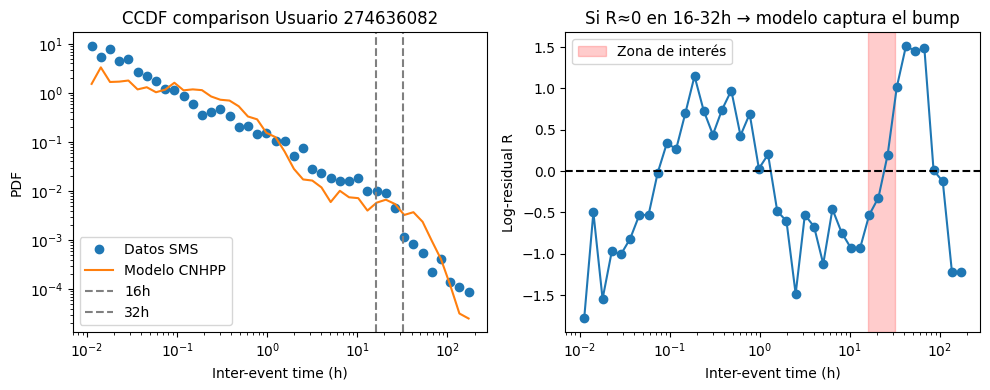

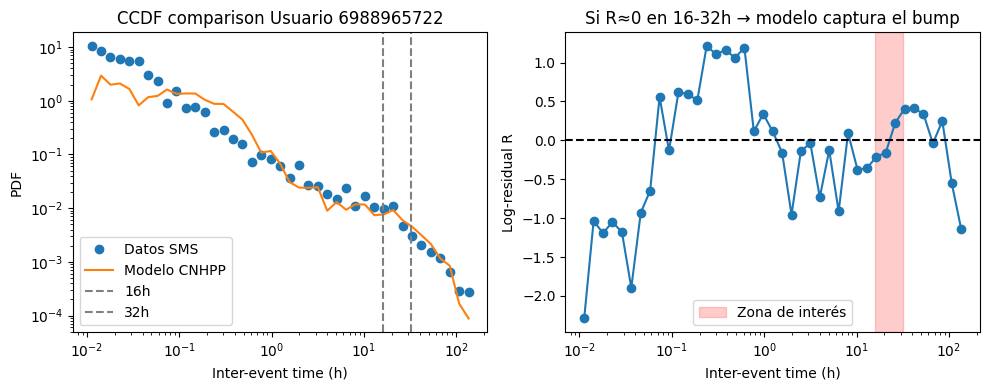

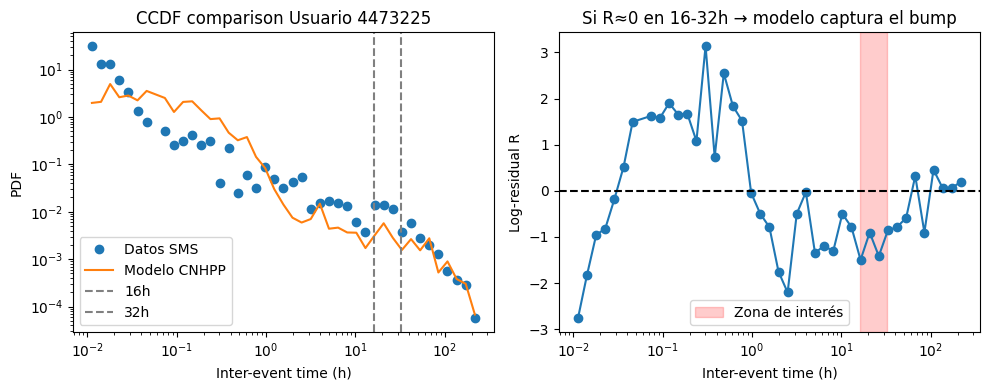

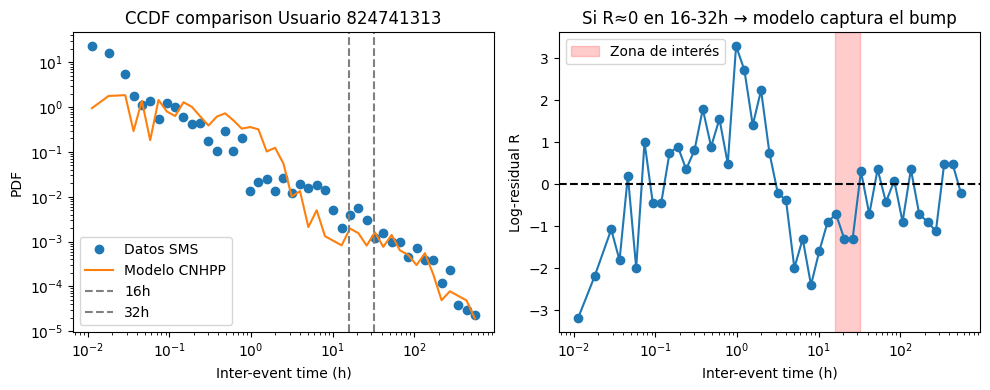

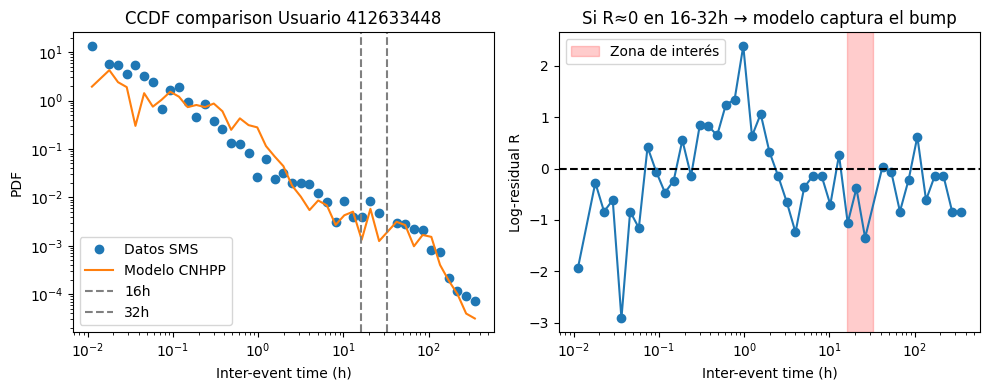

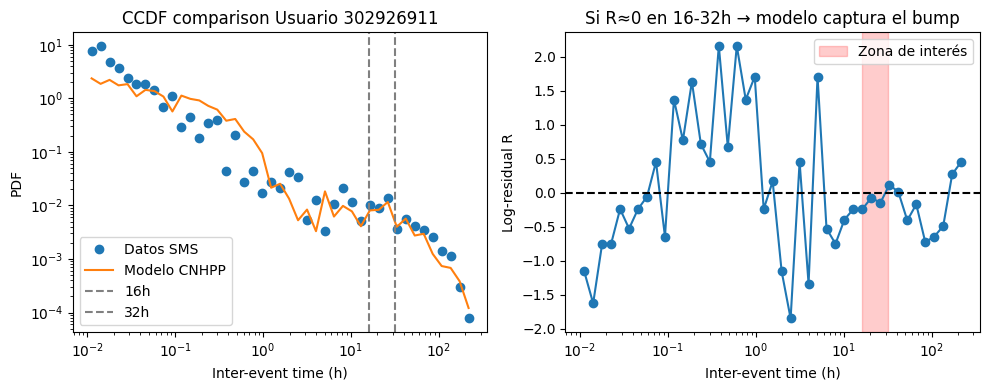

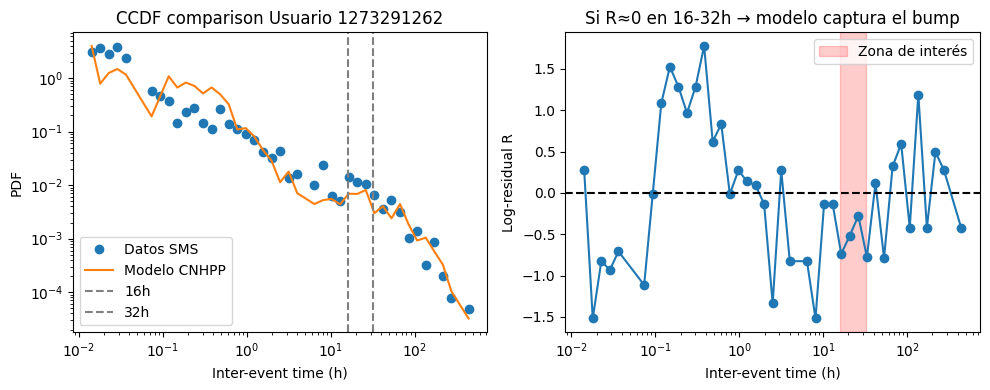

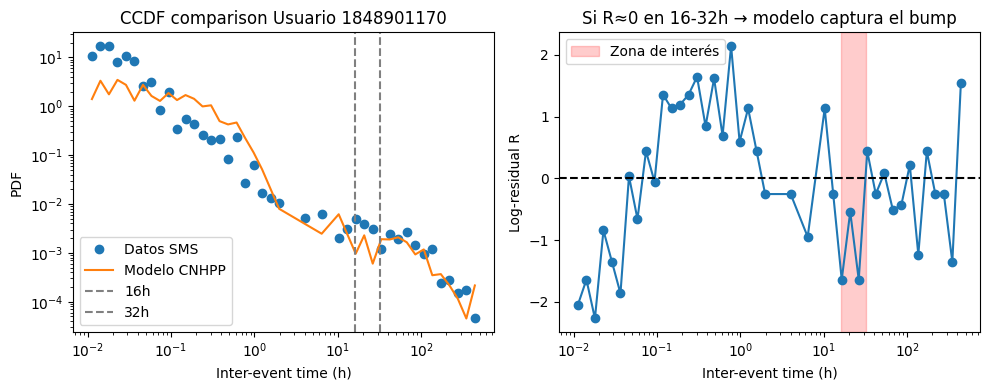

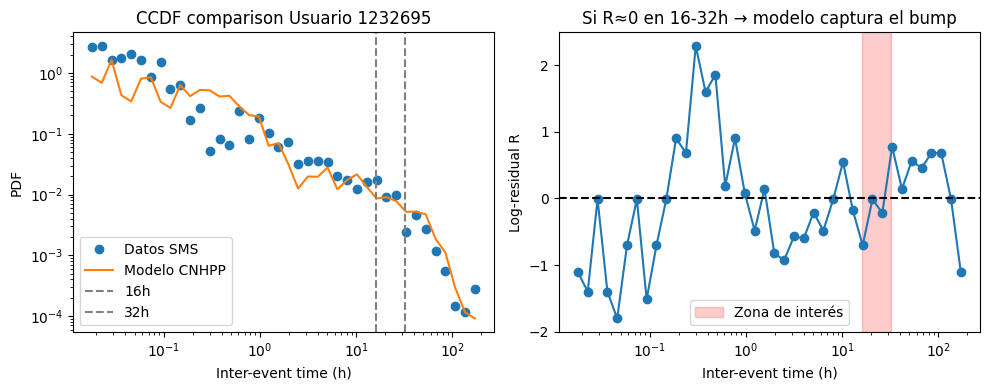

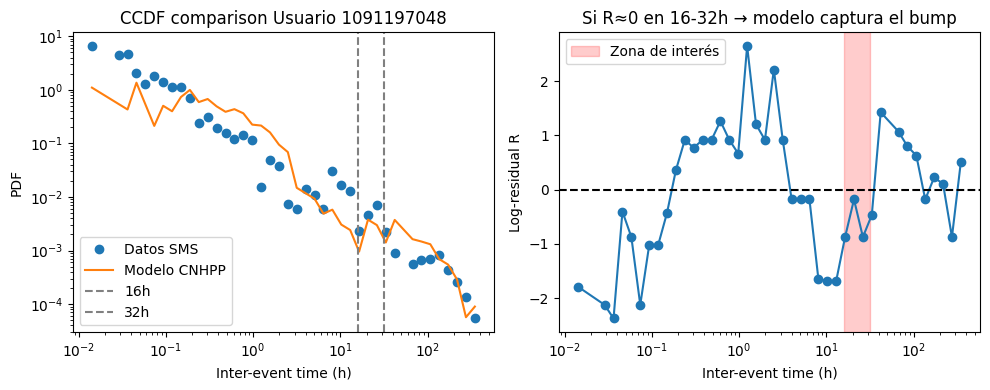

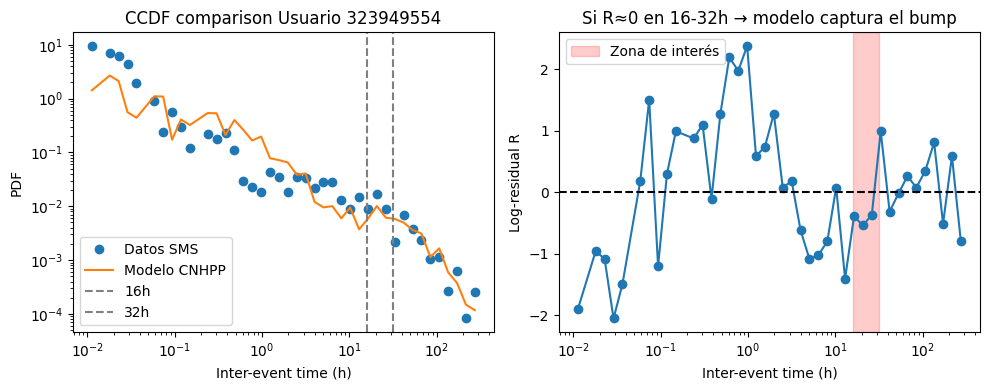

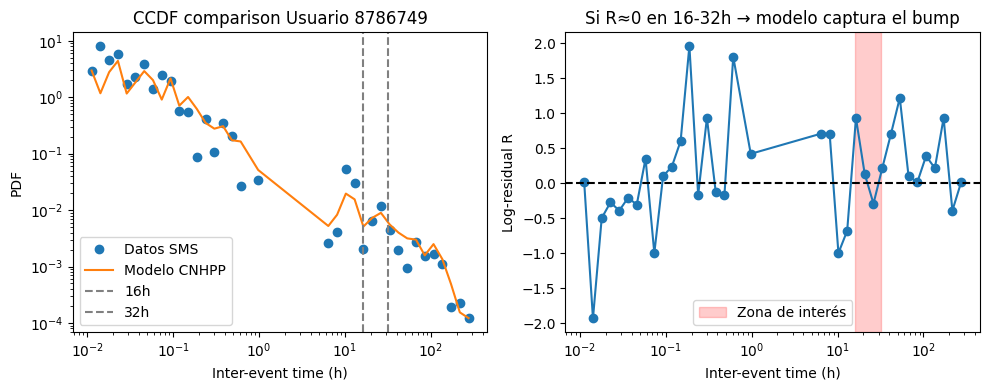

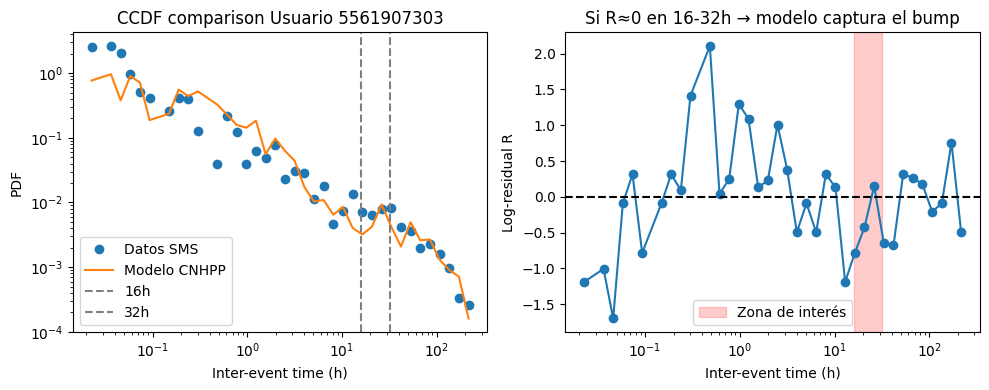

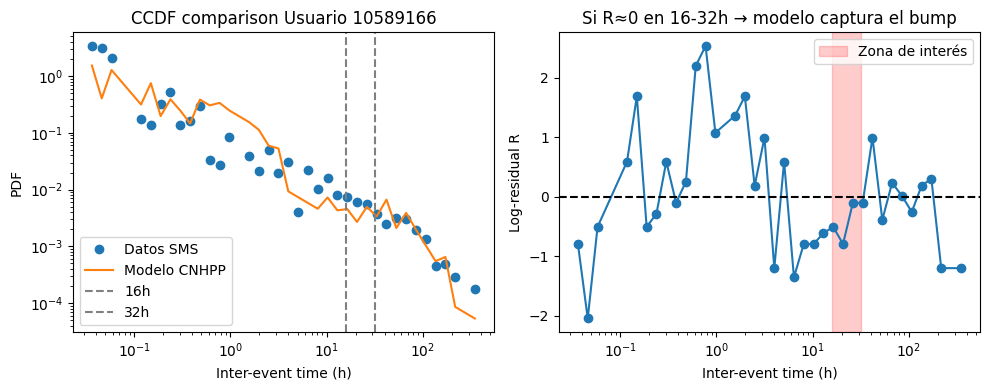

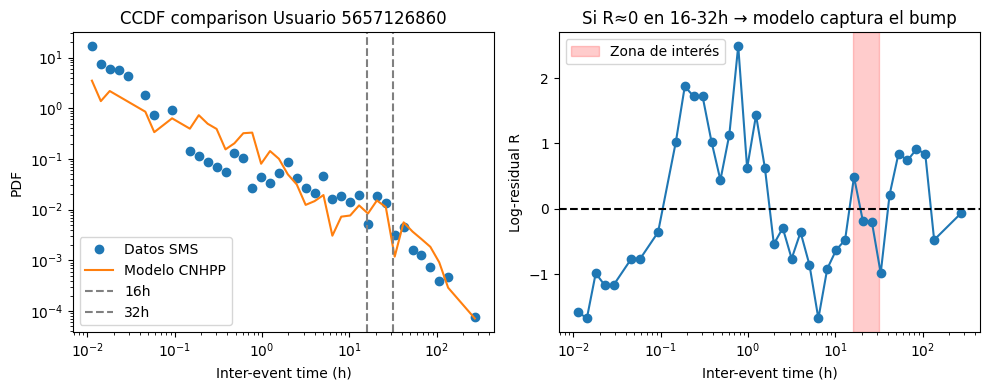

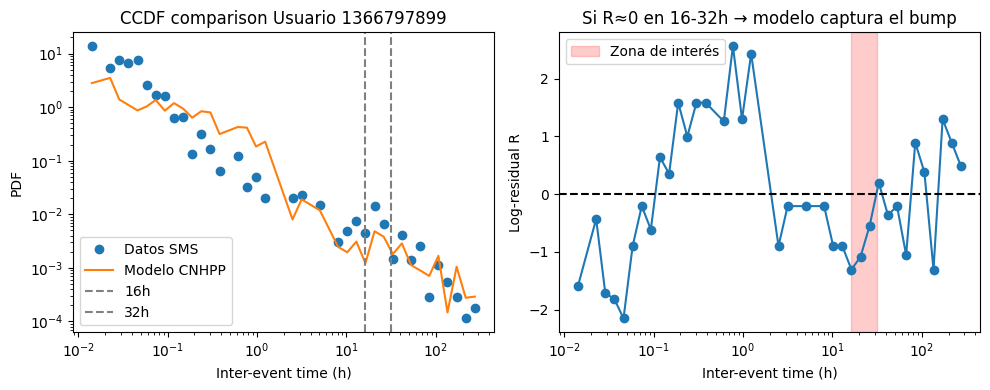

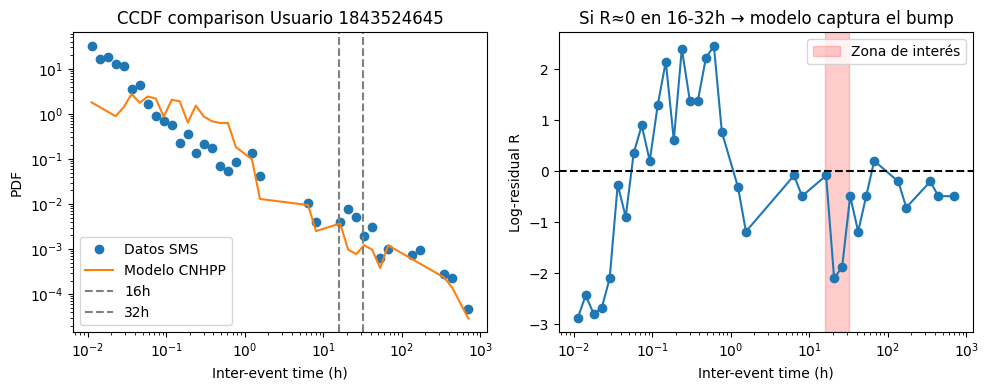

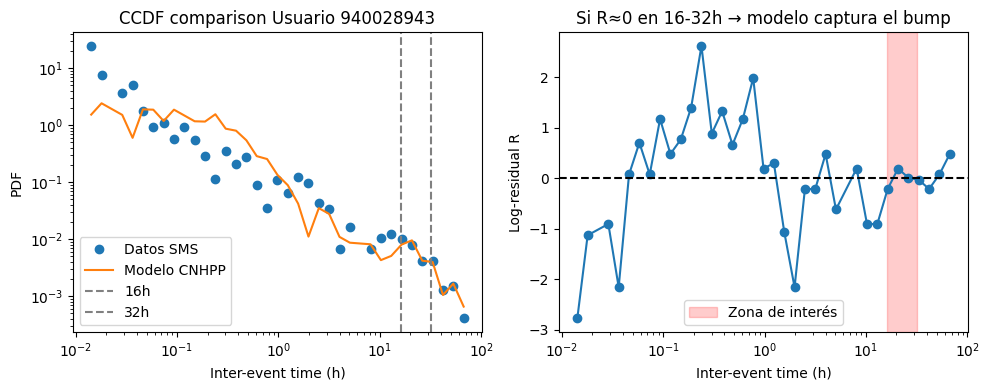

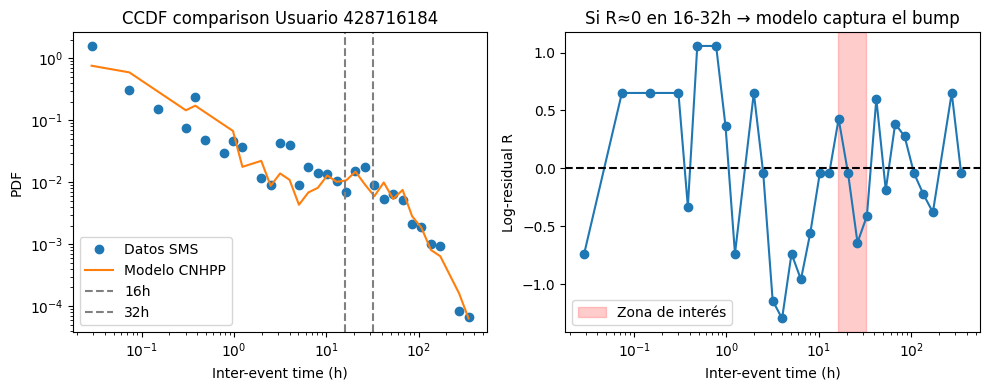

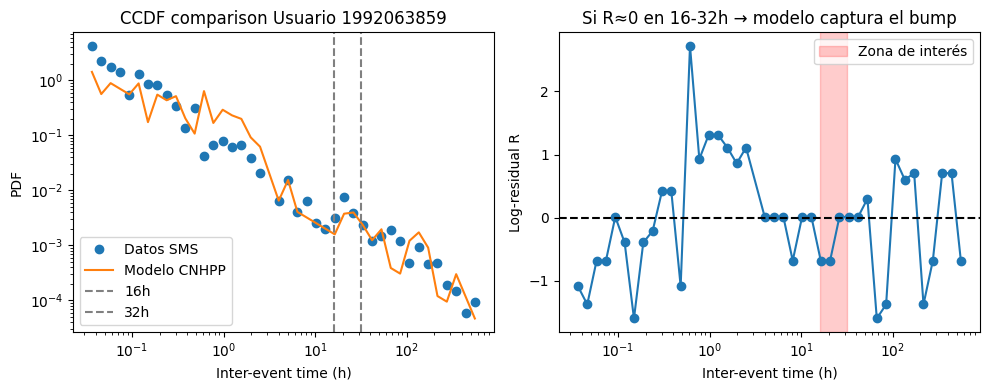

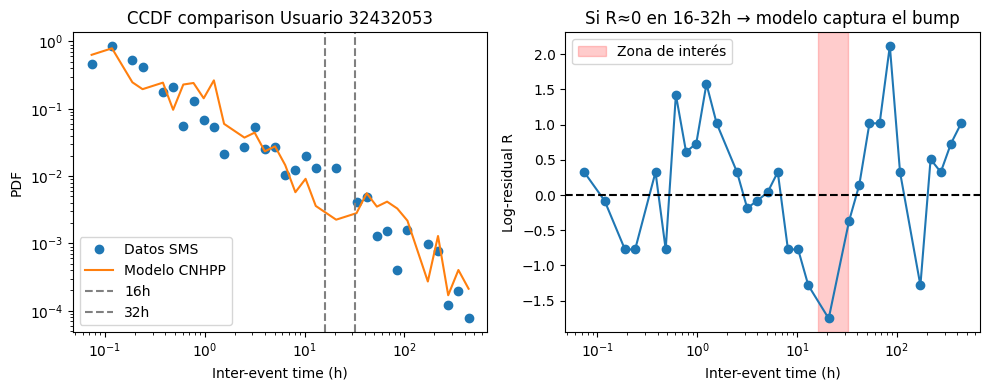

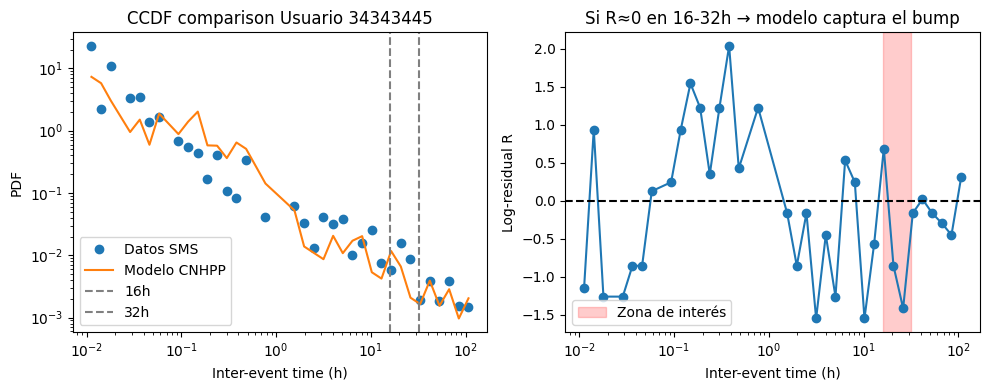

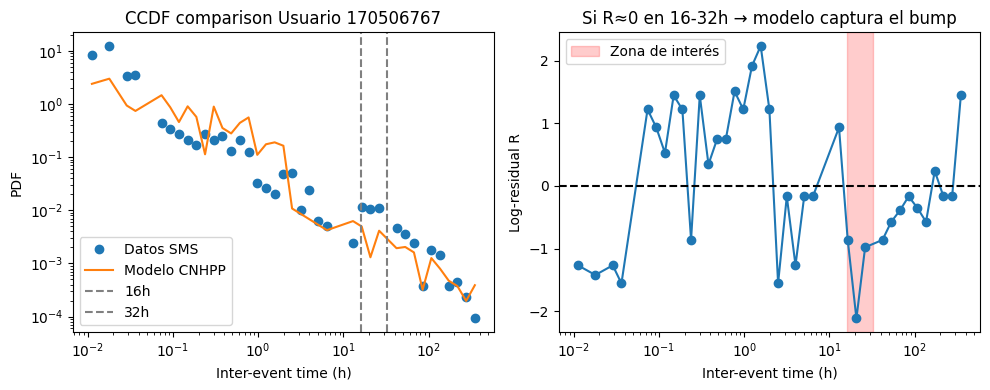

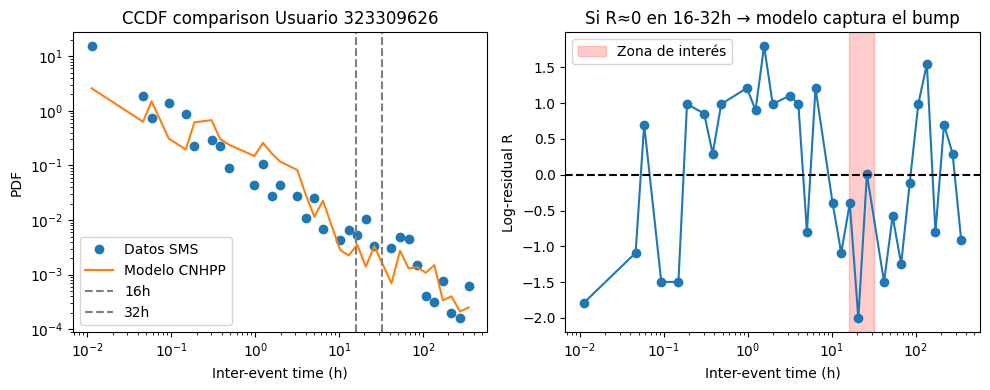

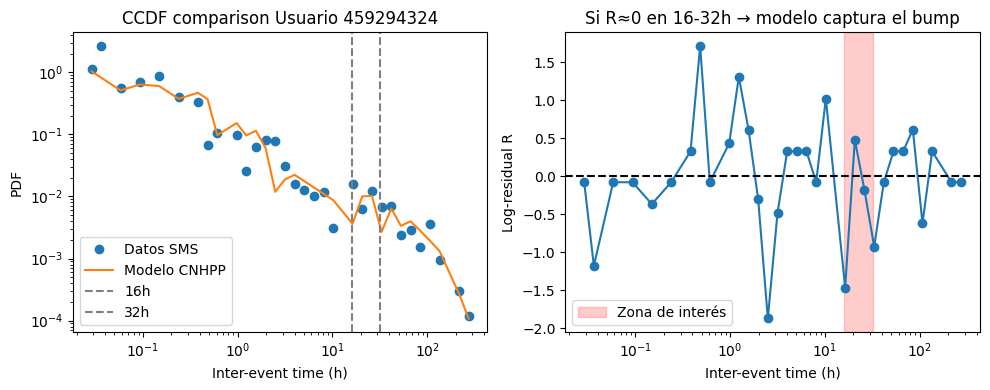

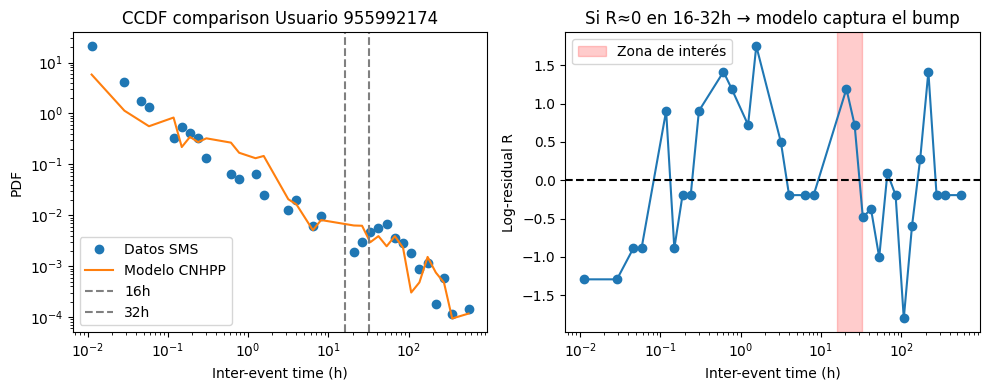

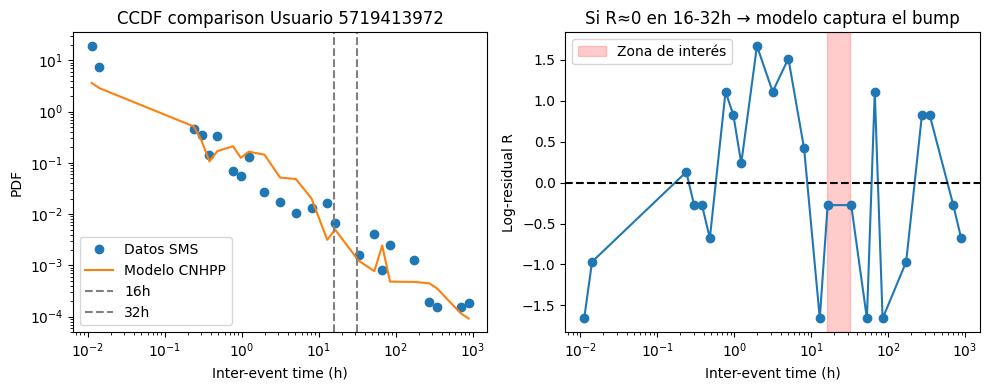

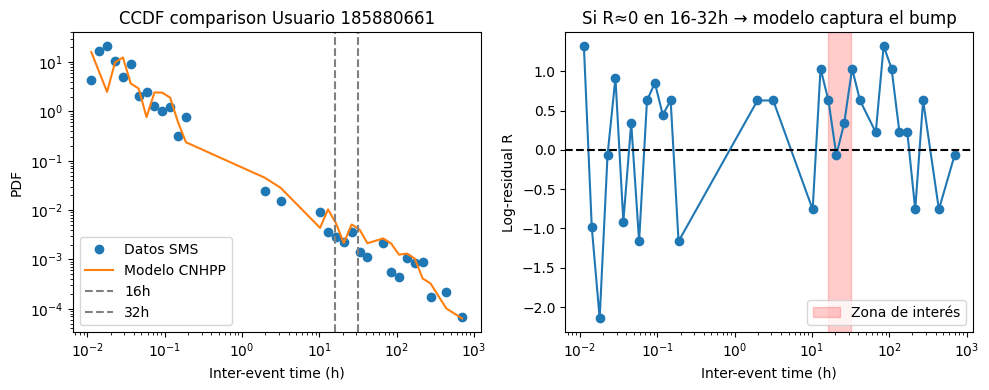

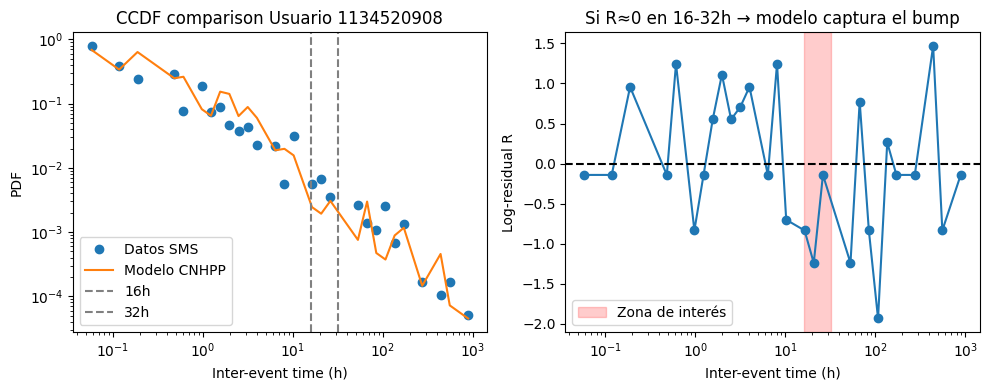

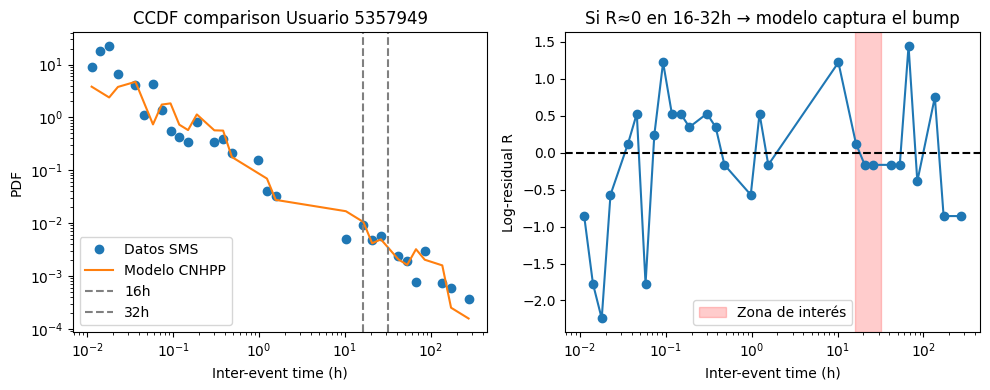

In [34]:
# Plot the log residuals for each user
for user_id in active_users:
    if user_id not in parameters_users:
        continue
    
    user_events = df[df['sender_id'] == user_id]['date'].sort_values()
    events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600
    empirical_iets = np.diff(events_hours.values)
    
    sim_events = simulated_cascades[user_id]
    simulated_iets = np.diff(sim_events)
    
    plot_log_residuals(empirical_iets, simulated_iets, title=f'Usuario {user_id}')  

## Save data

In [35]:
# Save info into csv for later analysis
results_df = pd.DataFrame({
    'user_id': list(parameters_users.keys()),
    'rho_a': [params['rho_a'] for params in parameters_users.values()],
    'pd_t': [params['pd_t'] for params in parameters_users.values()],
    'pw_t': [params['pw_t'] for params in parameters_users.values()],
    'p_Na': [params['p_Na'] for params in parameters_users.values()],
    'Nw': [params['Nw'] for params in parameters_users.values()],
    'A_best': [params['A_best'] for params in parameters_users.values()],
    'p_value': [pvalues_users.get(user_id, np.nan) for user_id in parameters_users.keys()]
})
results_df.to_csv('circadian_cycles_vagarenfe_2024_results.csv', index=False)

## Week-reshuffling test

**Null hypothesis:** The IET distribution depends only on `(weekday, time_of_day)` — the process is cyclostationary with a 1-week period.

**Procedure:** For each message, keep its `(weekday, HH:MM:SS)` fixed but randomly permute the week it belongs to. Reconstruct timestamps, recompute IETs, and compare the CCDF to the original. If the shuffled envelope contains the original curve, day+hour is sufficient. If not, week-level structure matters.

In [36]:
from scipy.stats import ks_2samp

def week_reshuffle_iets(dates, n_shuffles=200, seed=42):
    """
    Reshuffle messages between weeks keeping (weekday, time_of_day) fixed.

    Uses permutation (without replacement) of week labels so the marginal
    day-of-week and time-of-day distributions are exactly preserved.
    Returns (original_iets, list_of_shuffled_iets).
    """
    rng = np.random.default_rng(seed)
    dates = pd.Series(dates).dropna().sort_values().reset_index(drop=True)
    if len(dates) < 10:
        return None, None

    first_monday = dates.iloc[0] - pd.Timedelta(days=dates.iloc[0].weekday())
    week_num = ((dates - first_monday).dt.total_seconds() // (7 * 86400)).astype(int).values
    weekday  = dates.dt.weekday.values
    tod_sec  = (dates.dt.hour * 3600 + dates.dt.minute * 60 + dates.dt.second).values

    original_ts   = dates.values.astype('int64') / 1e9
    original_iets = np.diff(np.sort(original_ts))
    original_iets = original_iets[original_iets > 0]

    shuffled_iets_list = []
    for _ in range(n_shuffles):
        perm_weeks = rng.permutation(week_num)
        new_ts = (perm_weeks * 7 * 86400 + weekday * 86400 + tod_sec).astype(float)
        new_iets = np.diff(np.sort(new_ts))
        new_iets = new_iets[new_iets > 0]
        shuffled_iets_list.append(new_iets)

    return original_iets, shuffled_iets_list


def plot_reshuffle_ccdf(original_iets, shuffled_iets_list, title='', ax=None):
    """Plot original CCDF vs shuffled envelope (median + 5–95 percentile band)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    all_vals = np.concatenate([original_iets] + shuffled_iets_list)
    lo, hi   = np.percentile(all_vals[all_vals > 0], [0.1, 99.9])
    grid     = np.logspace(np.log10(lo), np.log10(hi), 300)

    def ccdf_on_grid(iets, g):
        return np.array([np.mean(iets > v) for v in g])

    orig_ccdf  = ccdf_on_grid(original_iets, grid)
    shuf_ccdfs = np.array([ccdf_on_grid(s, grid) for s in shuffled_iets_list])
    med = np.median(shuf_ccdfs, axis=0)
    p05 = np.percentile(shuf_ccdfs, 5,  axis=0)
    p95 = np.percentile(shuf_ccdfs, 95, axis=0)

    ax.fill_between(grid, p05, p95, alpha=0.25, color='steelblue', label='Shuffled 5–95%')
    ax.plot(grid, med,       color='steelblue', lw=1.5, ls='--', label='Shuffled median')
    ax.plot(grid, orig_ccdf, color='crimson',   lw=2,   label='Original')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('IET (seconds)'); ax.set_ylabel('CCDF  P(IET > τ)')
    ax.set_title(title); ax.legend(fontsize=8)
    ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.5)
    return ax

In [37]:
N_SHUFFLES = 200

reshuffle_results = {}

for user_id in active_users:
    user_dates = df[df['sender_id'] == user_id]['date'].dropna().sort_values()
    if len(user_dates) < 20:
        continue

    orig_iets, shuf_list = week_reshuffle_iets(user_dates, n_shuffles=N_SHUFFLES)
    if orig_iets is None:
        continue

    ks_orig_vs_mean_shuf = np.mean([ks_2samp(orig_iets, s).statistic for s in shuf_list])
    ks_null_dist = [ks_2samp(shuf_list[i], shuf_list[i+1]).statistic
                    for i in range(0, len(shuf_list)-1, 2)]
    pval_ks = np.mean(np.array(ks_null_dist) >= ks_orig_vs_mean_shuf)

    reshuffle_results[user_id] = {
        'orig_iets': orig_iets,
        'shuf_list': shuf_list,
        'ks_stat':   ks_orig_vs_mean_shuf,
        'pval_ks':   pval_ks,
    }

print(f"Processed {len(reshuffle_results)} users.")

Processed 30 users.


In [ ]:
# Empirical CCDF vs Reshuffled CCDF  (per-user PDF + combined multipage PDF)
from matplotlib.backends.backend_pdf import PdfPages

_sub = os.path.join(FIG_DIR, 'empirical_vs_reshuffled')
os.makedirs(_sub, exist_ok=True)
_combined = PdfPages(os.path.join(FIG_DIR, 'ALL_empirical_vs_reshuffled.pdf'))

_n = 0
for user_id, res in reshuffle_results.items():
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_reshuffle_ccdf(
        res['orig_iets'], res['shuf_list'],
        title=f'User {user_id} - Empirical vs Reshuffled  |  KS={res["ks_stat"]:.3f}  p={res["pval_ks"]:.3f}',
        ax=ax
    )
    fig.tight_layout()
    fig.savefig(os.path.join(_sub, f'user_{user_id}.pdf'), bbox_inches='tight')
    _combined.savefig(fig, bbox_inches='tight')
    plt.close(fig)
    _n += 1

_combined.close()
print(f'[empirical vs reshuffled] saved {_n} per-user PDFs in {_sub} + ALL_empirical_vs_reshuffled.pdf')


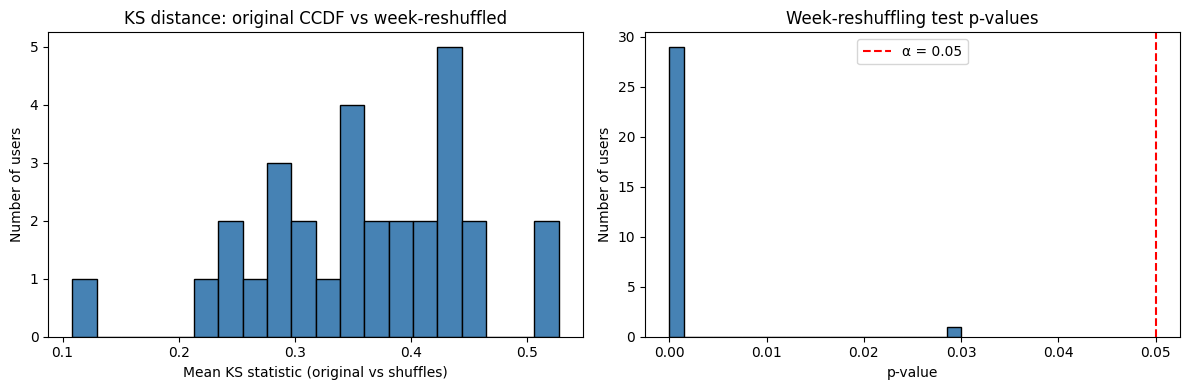

Users where null is rejected (p < 0.05): 30/30
→ For these users, day+hour alone does NOT explain the IET distribution.
  Additional structure (week-level trends, specific events) is present.


In [39]:
ks_stats = [v['ks_stat'] for v in reshuffle_results.values()]
pvals    = [v['pval_ks'] for v in reshuffle_results.values()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ks_stats, bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Mean KS statistic (original vs shuffles)')
axes[0].set_ylabel('Number of users')
axes[0].set_title('KS distance: original CCDF vs week-reshuffled')

axes[1].hist(pvals, bins=20, edgecolor='black', color='steelblue')
axes[1].axvline(0.05, color='red', ls='--', label='α = 0.05')
axes[1].set_xlabel('p-value')
axes[1].set_ylabel('Number of users')
axes[1].set_title('Week-reshuffling test p-values')
axes[1].legend()

plt.tight_layout()
plt.show()

n_rejected = sum(p < 0.05 for p in pvals)
print(f"Users where null is rejected (p < 0.05): {n_rejected}/{len(pvals)}")
print(f"→ For these users, day+hour alone does NOT explain the IET distribution.")
print(f"  Additional structure (week-level trends, specific events) is present.")

## Circadian model on reshuffled data

Sanity check: apply the full SA + NHPP pipeline to **one reshuffled sequence per user**.
The reshuffling preserves `(weekday, time-of-day)` but permutes weeks, removing week-to-week non-stationarity that the circadian model does not capture.
If the model is well-specified, it should retrieve the reshuffled IET distribution significantly better (higher p-values, lower area statistic).

In [40]:
# Load reshuffled SA results + p-values from CSV (skip recomputation if available)
RESHUFFLE_CSV = 'circadian_cycles_vagarenfe_2024_reshuffle_results.csv'

if os.path.exists(RESHUFFLE_CSV):
    saved_r = pd.read_csv(RESHUFFLE_CSV)
    reshuffle_model_results = {}
    reshuffle_pvalues       = {}
    for _, row in saved_r.iterrows():
        uid = int(row['user_id'])
        reshuffle_model_results[uid] = {
            'shuf_iets_h': np.array([]),          # not stored; recompute from reshuffle_results if needed
            'sim_events':  np.array([]),
            'rho_a':  float(row['rho_a']),
            'Nw':     float(row['Nw']),
            'pd_t':   _parse_array(row['pd_t']),
            'pw_t':   _parse_array(row['pw_t']),
            'p_Na':   _parse_array(row['p_Na']),
            'A_best': float(row['A_best']),
            'A_fit':  float(row['A_fit']),
        }
        reshuffle_pvalues[uid] = (
            float(row['p_value_reshuffle'])
            if 'p_value_reshuffle' in row and pd.notna(row['p_value_reshuffle'])
            else np.nan
        )
    print(f"Loaded {len(reshuffle_model_results)} reshuffled results from {RESHUFFLE_CSV} — skipping SA and Monte Carlo on reshuffle.")
else:
    reshuffle_model_results = None   # triggers SA below
    reshuffle_pvalues       = {}
    print(f"{RESHUFFLE_CSV} not found — will run SA and Monte Carlo on reshuffled data.")

circadian_cycles_vagarenfe_2024_reshuffle_results.csv not found — will run SA and Monte Carlo on reshuffled data.


In [41]:
# Run SA on one reshuffled sequence per user, then simulate NHPP and compare
# Skips automatically if reshuffle_model_results was already loaded from CSV.

RESHUFFLE_IDX = 0        # which shuffle to use (0 = first)
SA_ITER_SHUF  = 2000     # SA iterations on reshuffled data

i=0

if reshuffle_model_results is not None:
    print(f"Skipping SA on reshuffled data — {len(reshuffle_model_results)} users already loaded from CSV.")
else:
    reshuffle_model_results = {}
    for user_id, res in reshuffle_results.items():
        shuf_iets_sec = np.asarray(res['shuf_list'][RESHUFFLE_IDX], dtype=float)
        shuf_iets_sec = shuf_iets_sec[shuf_iets_sec > 0]
        if len(shuf_iets_sec) < 10:
            print(f"User {user_id}: too few IETs in reshuffle, skipping.")
            continue

        shuf_events_h = np.concatenate([[0.0], np.cumsum(shuf_iets_sec / 3600.0)])
        i += 1
        print(f"User {user_id}: running SA on reshuffled sequence (n_events={len(shuf_events_h)})... User ({i}/{len(active_users)})")

        best_cfg, A_best = simulated_annealing(shuf_events_h, n_iter=SA_ITER_SHUF)

        rho_a_s, Nw_s, pd_t_s, pw_t_s = compute_model_params(
            shuf_events_h, np.concatenate([[False], best_cfg])
        )
        p_Na_s = get_pNa(best_cfg)

        total_h    = shuf_events_h[-1]
        sim_events = simulate_cascading_nhpp(
            rho_a_s, Nw_s, pd_t_s, pw_t_s, p_Na_s,
            total_hours=total_h, n_samples=len(shuf_events_h)
        )
        A_fit = area_test_statistic(shuf_iets_sec / 3600.0, np.diff(sim_events)) if len(sim_events) > 1 else np.inf

        reshuffle_model_results[user_id] = {
            'shuf_iets_h': shuf_iets_sec / 3600.0,
            'sim_events':  sim_events,
            'rho_a':  rho_a_s, 'Nw': Nw_s,
            'pd_t':   pd_t_s,  'pw_t': pw_t_s,
            'p_Na':   p_Na_s,
            'A_best': A_best, 'A_fit': A_fit,
        }
        print(f"  A_best={A_best:.4f}  A_fit={A_fit:.4f}")

    print(f"\nDone: {len(reshuffle_model_results)} users processed.")

User 274636082: running SA on reshuffled sequence (n_events=1000)... User (1/30)
  Init: 40.6% pares mergeados  (threshold=1.4793h = 88.8min, candidatos=406/999)
  A_best=0.2537  A_fit=0.2152
User 6988965722: running SA on reshuffled sequence (n_events=723)... User (2/30)
  Init: 23.7% pares mergeados  (threshold=1.5526h = 93.2min, candidatos=171/722)
  A_best=0.0539  A_fit=0.1278
User 4473225: running SA on reshuffled sequence (n_events=617)... User (3/30)
  Init: 39.4% pares mergeados  (threshold=2.3638h = 141.8min, candidatos=243/616)
  A_best=0.2193  A_fit=0.3497
User 824741313: running SA on reshuffled sequence (n_events=404)... User (4/30)
  Init: 45.2% pares mergeados  (threshold=3.7935h = 227.6min, candidatos=182/403)
  A_best=0.4882  A_fit=0.4887
User 412633448: running SA on reshuffled sequence (n_events=393)... User (5/30)
  Init: 30.4% pares mergeados  (threshold=2.9864h = 179.2min, candidatos=119/392)
  A_best=0.1160  A_fit=0.1304
User 302926911: running SA on reshuffled s

In [ ]:
# Reshuffled CCDF vs Reshuffled CNHPP  (per-user PDF + combined multipage PDF)
from matplotlib.backends.backend_pdf import PdfPages

def plot_ccdf_comparison(iets_a, iets_b, label_a, label_b, ax, title=''):
    """Log-log CCDF of two IET arrays on the same axes."""
    for iets, label, color in [(iets_a, label_a, 'crimson'), (iets_b, label_b, 'steelblue')]:
        arr = np.asarray(iets, dtype=float)
        arr = arr[np.isfinite(arr) & (arr > 0)]
        if len(arr) == 0:
            continue
        x = np.sort(arr)
        y = 1.0 - np.arange(1, len(x) + 1) / len(x)
        ax.step(x, y, where='post', label=label, color=color, lw=1.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('IET (hours)'); ax.set_ylabel('CCDF')
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)
    ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.5)

RESHUFFLE_IDX = 0  # which reshuffle to use when reconstructing (matches SA cell)

_sub = os.path.join(FIG_DIR, 'reshuffled_vs_cnhpp')
os.makedirs(_sub, exist_ok=True)
_combined = PdfPages(os.path.join(FIG_DIR, 'ALL_reshuffled_vs_cnhpp.pdf'))

_n = 0
for user_id, res in reshuffle_model_results.items():
    shuf_iets_h = np.asarray(res.get('shuf_iets_h', []), dtype=float)
    sim_events  = np.asarray(res.get('sim_events', []),  dtype=float)

    # When results are loaded from CSV, shuf_iets_h / sim_events are empty:
    # reconstruct them from the stored model parameters + the reshuffled sequence.
    if (len(shuf_iets_h) < 2 or len(sim_events) < 2) and (user_id in reshuffle_results):
        shuf_iets_sec = np.asarray(reshuffle_results[user_id]['shuf_list'][RESHUFFLE_IDX], dtype=float)
        shuf_iets_sec = shuf_iets_sec[shuf_iets_sec > 0]
        if len(shuf_iets_sec) >= 2:
            shuf_iets_h   = shuf_iets_sec / 3600.0
            shuf_events_h = np.concatenate([[0.0], np.cumsum(shuf_iets_h)])
            sim_events = simulate_cascading_nhpp(
                res['rho_a'], res['Nw'], res['pd_t'], res['pw_t'], res['p_Na'],
                total_hours=shuf_events_h[-1], n_samples=len(shuf_events_h)
            )

    sim_events = np.asarray(sim_events, dtype=float)
    if len(sim_events) < 2 or len(shuf_iets_h) < 2:
        continue
    sim_iets_h = np.diff(sim_events)

    fig, ax = plt.subplots(figsize=(7, 5))
    plot_ccdf_comparison(
        shuf_iets_h, sim_iets_h,
        'Reshuffled', 'CNHPP (fitted on reshuffle)',
        ax, title=f'User {user_id} - Reshuffled vs CNHPP  A_fit={res["A_fit"]:.4f}'
    )
    fig.tight_layout()
    fig.savefig(os.path.join(_sub, f'user_{user_id}.pdf'), bbox_inches='tight')
    _combined.savefig(fig, bbox_inches='tight')
    plt.close(fig)
    _n += 1

_combined.close()
print(f'[reshuffled vs CNHPP] saved {_n} per-user PDFs in {_sub} + ALL_reshuffled_vs_cnhpp.pdf')

# Summary: distribution of area statistics on original vs reshuffled
orig_A_vals = [parameters_users[uid]['A_best'] for uid in reshuffle_model_results if uid in parameters_users]
shuf_A_vals = [reshuffle_model_results[uid]['A_best'] for uid in reshuffle_model_results if uid in parameters_users]
if orig_A_vals and shuf_A_vals:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(orig_A_vals, bins=20, alpha=0.6, color='crimson',   label='Original data',   edgecolor='black')
    ax.hist(shuf_A_vals, bins=20, alpha=0.6, color='steelblue', label='Reshuffled data', edgecolor='black')
    ax.set_xlabel('Area statistic A_best (lower = better fit)')
    ax.set_ylabel('Number of users')
    ax.set_title('Model fit quality: original vs reshuffled sequences')
    ax.axvline(np.median(orig_A_vals), color='crimson',   ls='--', lw=1.5)
    ax.axvline(np.median(shuf_A_vals), color='steelblue', ls='--', lw=1.5)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'summary_area_statistic_hist.pdf'), bbox_inches='tight')
    plt.close(fig)
    from scipy.stats import wilcoxon
    stat, pval = wilcoxon(orig_A_vals, shuf_A_vals, alternative='greater')
    print(f"Wilcoxon (original > reshuffled): stat={stat:.1f}, p={pval:.4f}")
    print(f"Median A_best -- original: {np.median(orig_A_vals):.4f} | reshuffled: {np.median(shuf_A_vals):.4f}")


Monte Carlo for user 274636082 (reshuffled, M=20)... User (1/30)
  Monte Carlo réplica 1/20...
  Init: 32.4% pares mergeados  (threshold=1.4477h = 86.9min, candidatos=324/999)
  Monte Carlo réplica 2/20...
  Init: 37.0% pares mergeados  (threshold=1.3509h = 81.1min, candidatos=370/999)
  Monte Carlo réplica 3/20...
  Init: 38.2% pares mergeados  (threshold=1.4547h = 87.3min, candidatos=382/999)
  Monte Carlo réplica 4/20...
  Init: 40.1% pares mergeados  (threshold=1.4594h = 87.6min, candidatos=401/999)
  Monte Carlo réplica 5/20...
  Init: 39.1% pares mergeados  (threshold=1.3897h = 83.4min, candidatos=391/999)
  Monte Carlo réplica 6/20...
  Init: 37.7% pares mergeados  (threshold=1.4730h = 88.4min, candidatos=377/999)
  Monte Carlo réplica 7/20...
  Init: 38.2% pares mergeados  (threshold=1.3041h = 78.2min, candidatos=382/999)
  Monte Carlo réplica 8/20...
  Init: 36.1% pares mergeados  (threshold=1.4436h = 86.6min, candidatos=361/999)
  Monte Carlo réplica 9/20...
  Init: 36.1% par

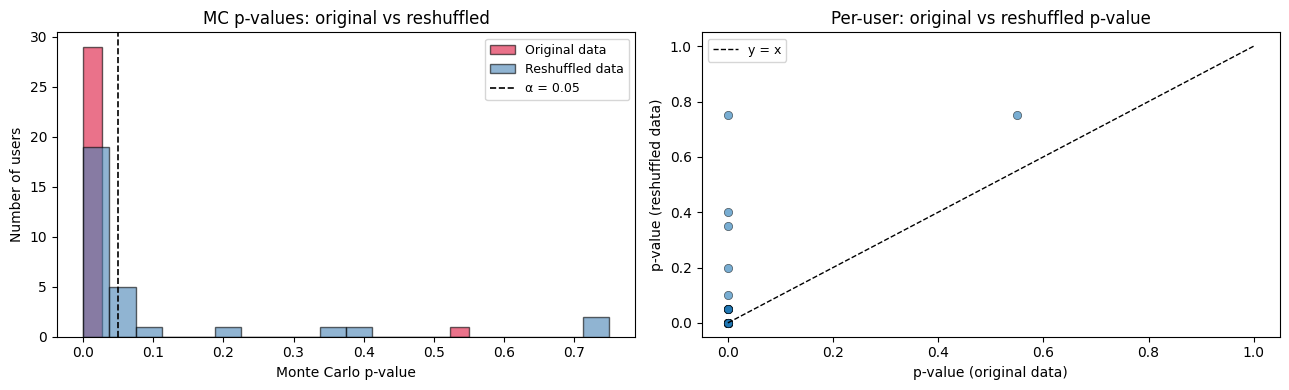

Original   — rejected at 0.05: 29/30
Reshuffled — rejected at 0.05: 19/30


In [43]:
# Monte Carlo hypothesis test on reshuffled data
# Skips automatically if p-values were already loaded from CSV.

MC_M       = 20    # replicas (use 100 for final results)
MC_SA_ITER = 2000  # SA iterations per replica

i=0

if reshuffle_pvalues and all(not np.isnan(v) for v in reshuffle_pvalues.values() if v is not None):
    print(f"Skipping Monte Carlo on reshuffled data — {len(reshuffle_pvalues)} p-values already loaded from CSV.")
else:
    for user_id, res in reshuffle_model_results.items():
        if user_id in reshuffle_pvalues and not np.isnan(reshuffle_pvalues.get(user_id, np.nan)):
            print(f"Skipping user {user_id} — reshuffled p-value already available.")
            continue

        shuf_iets_h = np.asarray(res.get('shuf_iets_h', []), dtype=float)
        # If shuf_iets_h not stored (loaded from CSV), recompute from reshuffle_results
        if len(shuf_iets_h) == 0 and user_id in reshuffle_results:
            shuf_iets_sec = np.asarray(reshuffle_results[user_id]['shuf_list'][0], dtype=float)
            shuf_iets_h   = shuf_iets_sec[shuf_iets_sec > 0] / 3600.0
        if len(shuf_iets_h) < 10:
            continue

        total_h      = float(np.sum(shuf_iets_h))
        model_params = (res['rho_a'], res['Nw'], res['pd_t'], res['pw_t'], res['p_Na'], total_h)

        i += 1
        print(f"Monte Carlo for user {user_id} (reshuffled, M={MC_M})... User ({i}/{len(active_users)})")
        p_val = monte_carlo_pvalue(shuf_iets_h, model_params, M=MC_M, sa_iter=MC_SA_ITER)
        reshuffle_pvalues[user_id] = p_val
        print(f"  p = {p_val:.4f}")

# ── Summary comparison ────────────────────────────────────────────────────────
orig_pvals = [pvalues_users.get(uid, np.nan) for uid in reshuffle_pvalues]
shuf_pvals = [reshuffle_pvalues[uid]         for uid in reshuffle_pvalues]

orig_valid = [p for p in orig_pvals if not np.isnan(p)]
shuf_valid = [p for p in shuf_pvals if not np.isnan(p)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(orig_valid, bins=20, alpha=0.6, color='crimson',
             edgecolor='black', label='Original data')
axes[0].hist(shuf_valid, bins=20, alpha=0.6, color='steelblue',
             edgecolor='black', label='Reshuffled data')
axes[0].axvline(0.05, color='k', ls='--', lw=1.2, label='α = 0.05')
axes[0].set_xlabel('Monte Carlo p-value')
axes[0].set_ylabel('Number of users')
axes[0].set_title('MC p-values: original vs reshuffled')
axes[0].legend(fontsize=9)

common = [(pvalues_users.get(uid, np.nan), reshuffle_pvalues[uid])
          for uid in reshuffle_pvalues
          if not np.isnan(pvalues_users.get(uid, np.nan))]
if common:
    ox, sy = zip(*common)
    axes[1].scatter(ox, sy, alpha=0.6, edgecolors='black', linewidths=0.5)
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='y = x')
    axes[1].set_xlabel('p-value (original data)')
    axes[1].set_ylabel('p-value (reshuffled data)')
    axes[1].set_title('Per-user: original vs reshuffled p-value')
    axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

n_orig_rejected = sum(p < 0.05 for p in orig_valid)
n_shuf_rejected = sum(p < 0.05 for p in shuf_valid)
print(f"Original   — rejected at 0.05: {n_orig_rejected}/{len(orig_valid)}")
print(f"Reshuffled — rejected at 0.05: {n_shuf_rejected}/{len(shuf_valid)}")

In [44]:
# Save reshuffled SA parameters + Monte Carlo p-values to CSV
reshuffle_save_df = pd.DataFrame({
    'user_id': list(reshuffle_model_results.keys()),
    'rho_a':   [r['rho_a']  for r in reshuffle_model_results.values()],
    'Nw':      [r['Nw']     for r in reshuffle_model_results.values()],
    'pd_t':    [r['pd_t']   for r in reshuffle_model_results.values()],
    'pw_t':    [r['pw_t']   for r in reshuffle_model_results.values()],
    'p_Na':    [r['p_Na']   for r in reshuffle_model_results.values()],
    'A_best':  [r['A_best'] for r in reshuffle_model_results.values()],
    'A_fit':   [r['A_fit']  for r in reshuffle_model_results.values()],
    'p_value_reshuffle': [reshuffle_pvalues.get(uid, np.nan)
                          for uid in reshuffle_model_results.keys()],
})
reshuffle_save_df.to_csv('circadian_cycles_vagarenfe_2024_reshuffle_results.csv', index=False)
print(f"Saved {len(reshuffle_save_df)} rows to circadian_cycles_vagarenfe_2024_reshuffle_results.csv")

Saved 30 rows to circadian_cycles_vagarenfe_2024_reshuffle_results.csv


In [45]:
#print the p-values for reshuffled data
print("\nP-valores de usuarios activos (reshuffled):")
for user_id, p_value in reshuffle_pvalues.items():
    print(f"Usuario {user_id}: p-valor={p_value:.4f}")


P-valores de usuarios activos (reshuffled):
Usuario 274636082: p-valor=0.0000
Usuario 6988965722: p-valor=0.0500
Usuario 4473225: p-valor=0.0000
Usuario 824741313: p-valor=0.0000
Usuario 412633448: p-valor=0.2000
Usuario 302926911: p-valor=0.3500
Usuario 1273291262: p-valor=0.0000
Usuario 1848901170: p-valor=0.0000
Usuario 1232695: p-valor=0.0000
Usuario 1091197048: p-valor=0.0000
Usuario 323949554: p-valor=0.0500
Usuario 8786749: p-valor=0.7500
Usuario 5561907303: p-valor=0.0000
Usuario 10589166: p-valor=0.0500
Usuario 5657126860: p-valor=0.0000
Usuario 1366797899: p-valor=0.0000
Usuario 1843524645: p-valor=0.0000
Usuario 940028943: p-valor=0.0500
Usuario 428716184: p-valor=0.0500
Usuario 1992063859: p-valor=0.1000
Usuario 32432053: p-valor=0.0000
Usuario 34343445: p-valor=0.7500
Usuario 170506767: p-valor=0.0000
Usuario 323309626: p-valor=0.0000
Usuario 459294324: p-valor=0.4000
Usuario 955992174: p-valor=0.0000
Usuario 5719413972: p-valor=0.0000
Usuario 185880661: p-valor=0.0000
Us